In [1]:
import pandas as pd
df = pd.read_csv("data/tripadvisor_european_restaurants.csv", low_memory=False)

In [2]:
df.shape

(1083397, 42)

In [3]:
df.columns.tolist()

['restaurant_link',
 'restaurant_name',
 'original_location',
 'country',
 'region',
 'province',
 'city',
 'address',
 'latitude',
 'longitude',
 'claimed',
 'awards',
 'popularity_detailed',
 'popularity_generic',
 'top_tags',
 'price_level',
 'price_range',
 'meals',
 'cuisines',
 'special_diets',
 'features',
 'vegetarian_friendly',
 'vegan_options',
 'gluten_free',
 'original_open_hours',
 'open_days_per_week',
 'open_hours_per_week',
 'working_shifts_per_week',
 'avg_rating',
 'total_reviews_count',
 'default_language',
 'reviews_count_in_default_language',
 'excellent',
 'very_good',
 'average',
 'poor',
 'terrible',
 'food',
 'service',
 'value',
 'atmosphere',
 'keywords']

In [4]:
# look at cities in Ireland
print(df[df["country"] == "Ireland"]["city"].unique())

['Palmerstown' 'Clane' 'Glencolmcille' 'Rosscarbery' 'Charleville'
 'Castlebridge' 'Camp' 'Kilfenora' 'Carran' 'Sandyford' 'Ballylanders'
 'Borris' 'Belturbet' 'Cootehill' 'Swinford' 'Booterstown' 'Kingswood'
 'Stillorgan' 'Blackrock' 'Kinsealy' 'Templeogue' 'Cratloe' 'Athenry'
 'Greencastle' 'Dunmore East' 'Kilrush' 'Pettigo' 'Coachford' 'Barna'
 'Duleek' 'Castlebellingham' 'Courtmacsherry' 'New Quay' 'Dunboyne'
 'Cloghran' 'Roscrea' 'Ross' 'Ballyheige' 'Tyrrelstown' 'Ballylickey'
 'Rathfarnham' 'Castlebaldwin' 'Mountcharles' 'Claregalway' 'Renmore'
 'Ballaghaderreen' 'Portarlington' 'Banagher' 'Bushypark' 'Craughwell'
 'Furbo' 'Terryland' 'Glandore' 'Ballyconneely' 'Downings' 'Summerhill'
 'Clonbur' 'Ardpatrick' 'Clonmany' 'Drinagh' 'Glasson' 'Courtown' 'Dromod'
 'Ballinrobe' 'Tinahely' 'Knightstown' 'Terryglass' 'Minane Bridge'
 'Ovens' 'Tullow' 'Borrisokane' 'Cloondara' 'Curry' 'Granard' 'Ardgroom'
 'Banna' 'Mullinavat' 'Carrigallen' 'Liscannor' 'Bere Island'
 'Ballinskelligs' 'Ash

In [5]:
dublin = df[df["city"] == "Dublin"].copy()
dublin.shape

(2749, 42)

In [6]:
dublin.head()

,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
876628,g186605-d10004041,Vape Caffè,"[""Europe"", ""Ireland"", ""Province of Leinster"", ...",Ireland,Province of Leinster,County Dublin,Dublin,"85, Capel Street, Dublin Ireland",53.350870,-6.270030,...,2.0,1.0,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN
876629,g186605-d10004867,Pickle,"[""Europe"", ""Ireland"", ""Province of Leinster"", ...",Ireland,Province of Leinster,County Dublin,Dublin,"43 Camden Street, Dublin Ireland",53.333908,-6.265144,...,523.0,123.0,32.0,14.0,13.0,4.5,4.5,4.0,NaN,"butter chicken, curry, naan, boar, prawns"
876630,g186605-d10021173,Bunsen South Anne Street,"[""Europe"", ""Ireland"", ""Province of Leinster"", ...",Ireland,Province of Leinster,County Dublin,Dublin,"3 South Anne Street Dublin 2, Dublin Ireland",53.341210,-6.260114,...,171.0,52.0,14.0,9.0,17.0,4.5,4.0,4.5,NaN,"burger, fries, potatoes, business card, simple..."
876631,g186605-d10021746,Craft,"[""Europe"", ""Ireland"", ""Province of Leinster"", ...",Ireland,Province of Leinster,County Dublin,Dublin,"208 Harold's Cross Rd, Dublin 6W Ireland",53.322556,-6.279444,...,85.0,31.0,2.0,3.0,0.0,4.5,5.0,4.5,NaN,"roast potatoes, mains and desserts, venison, t..."
876632,g186605-d10026628,U Cafe,"[""Europe"", ""Ireland"", ""Province of Leinster"", ...",Ireland,Province of Leinster,County Dublin,Dublin,"30 James Street, Dublin Dublin 8 Ireland",53.343224,-6.290726,...,6.0,11.0,2.0,2.0,1.0,3.5,4.5,4.0,NaN,NaN


In [7]:
# missing values per column (count & percentage)
missing = pd.DataFrame({
    "missing_count": dublin.isnull().sum(),
    "missing_percent": (dublin.isnull().mean() * 100).round(1)
})
missing.sort_values("missing_percent", ascending=False)

,missing_count,missing_percent
keywords,2058,74.9
features,2010,73.1
atmosphere,1909,69.4
awards,1878,68.3
price_range,1851,67.3
special_diets,1636,59.5
working_shifts_per_week,1226,44.6
open_hours_per_week,1226,44.6
open_days_per_week,1226,44.6
original_open_hours,1226,44.6


In [8]:
# Dropping the following columns

# 1. Columns that are too sparse to use reliably (≥40% missing)
sparse_cols = ["keywords", "features", "atmosphere", "awards", "price_range", "special_diets", "meals", "food", "service", "value"]

# 2. Opening hours/shifts - approx 45% missing & it is not relevant in matching venues to tastes
hours_cols = ["original_open_hours", "open_days_per_week", "open_hours_per_week", "working_shifts_per_week"]

# 3. Not useful for matching
irrelevant_cols = ["original_location", "country", "region", "province", "city", "claimed", "default_language", "popularity_detailed", "popularity_generic", "reviews_count_in_default_language"]

cols_to_drop = sparse_cols + hours_cols + irrelevant_cols

dublin_clean = dublin.drop(columns=cols_to_drop)

print("Dropped:", len(cols_to_drop), "columns")

print("Remaining shape:", dublin_clean.shape)

dublin_clean.columns.tolist()

Dropped: 24 columns
Remaining shape: (2749, 18)


['restaurant_link',
 'restaurant_name',
 'address',
 'latitude',
 'longitude',
 'top_tags',
 'price_level',
 'cuisines',
 'vegetarian_friendly',
 'vegan_options',
 'gluten_free',
 'avg_rating',
 'total_reviews_count',
 'excellent',
 'very_good',
 'average',
 'poor',
 'terrible']

In [9]:
# check which rows are missing both cuisines and top_tags
not_match = dublin_clean[dublin_clean["cuisines"].isnull() & dublin_clean["top_tags"].isnull()]
print("Unmatchable rows (rows with no cuisines and no tags):", len(not_match))

Unmatchable rows (rows with no cuisines and no tags): 250


In [10]:
# how many are missing individually

print("Missing values for cuisines:", dublin_clean["cuisines"].isnull().sum())
print("Missing values for top_tags:", dublin_clean["top_tags"].isnull().sum())

Missing values for cuisines: 395
Missing values for top_tags: 250


In [11]:
# handling missing values on the key columns

# 1. Dropping rows that cannot be matched at all (no cuisines and no top_tags)
dublin_clean = dublin_clean[~(dublin_clean["cuisines"].isnull() & dublin_clean["top_tags"].isnull())].copy()

# 2. Fill missing price_level with "Unknown"
dublin_clean["price_level"] = dublin_clean["price_level"].fillna("Unknown")

print("Rows after cleaning:", len(dublin_clean))

Rows after cleaning: 2499


In [12]:
# Confirm the matching columns are clean

print("Rows missing BOTH cuisine and top_tags:", (dublin_clean["cuisines"].isnull() & dublin_clean["top_tags"].isnull()).sum())

print("Missing price_level:", dublin_clean["price_level"].isnull().sum())
print("Missing top_tags:", dublin_clean["top_tags"].isnull().sum())
print("Missing cuisines:", dublin_clean["cuisines"].isnull().sum())

Rows missing BOTH cuisine and top_tags: 0
Missing price_level: 0
Missing top_tags: 0
Missing cuisines: 145


In [13]:
# Check the most common cuisines in Dublin
dublin_clean["cuisines"].value_counts().head(15)

cuisines
Cafe                         241
Irish                         80
Irish, Bar, Pub               71
Irish, Bar, European, Pub     51
Fast food                     51
Irish, European               47
Irish, Cafe, European         44
Chinese                       43
Pizza                         43
Bar, Pub                      40
Irish, Cafe                   36
Asian, Thai                   33
Italian, Pizza, European      33
Chinese, Asian                31
Italian                       30
Name: count, dtype: int64

In [14]:
# Check the most common top_tags in Dublin
dublin_clean["top_tags"].value_counts().head(15)

top_tags
Mid-range, Irish, Bar, European                    129
Mid-range, Irish, Bar, Pub                          92
Cheap Eats, Cafe                                    50
Cafe                                                46
Mid-range, Italian, Pizza, European                 44
Mid-range, Irish, Cafe, European                    44
Mid-range                                           37
Mid-range, Irish, European, Vegetarian Friendly     37
Mid-range, Japanese, Sushi, Asian                   35
Irish                                               32
Chinese                                             28
Mid-range, Cafe                                     27
Fast food                                           26
Mid-range, Bar, Pub                                 24
Pizza                                               24
Name: count, dtype: int64

In [15]:
dublin_clean["price_level"].value_counts()

price_level
€€-€€€     1442
€           594
Unknown     416
€€€€         47
Name: count, dtype: int64

In [16]:
# summary statistics
dublin_clean.describe()

,latitude,longitude,avg_rating,total_reviews_count,excellent,very_good,average,poor,terrible
count,2478.000000,2478.000000,2352.000000,2352.000000,2353.000000,2353.000000,2353.000000,2353.000000,2353.000000
mean,53.342050,-6.262551,4.027849,187.969813,87.679558,40.340416,14.505737,7.817255,8.599660
std,0.030323,0.047950,0.669067,443.436467,211.214043,92.885029,32.274480,16.328700,16.280974
min,53.144333,-6.500919,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,53.332898,-6.269457,3.500000,12.000000,5.000000,2.000000,1.000000,0.000000,1.000000
50%,53.343085,-6.262103,4.000000,44.000000,19.000000,9.000000,3.000000,2.000000,3.000000
75%,53.350187,-6.247879,4.500000,162.000000,72.000000,36.000000,14.000000,8.000000,9.000000
max,53.613170,-6.062007,5.000000,6464.000000,3111.000000,1339.000000,377.000000,210.000000,187.000000


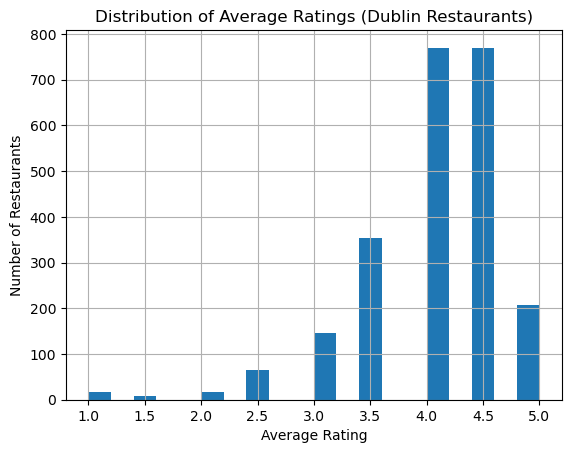

In [17]:
import matplotlib.pyplot as plt

# distribution of avg_rating

dublin_clean["avg_rating"].hist(bins=20)
plt.title("Distribution of Average Ratings (Dublin Restaurants)")
plt.xlabel("Average Rating")
plt.ylabel("Number of Restaurants")
plt.show()

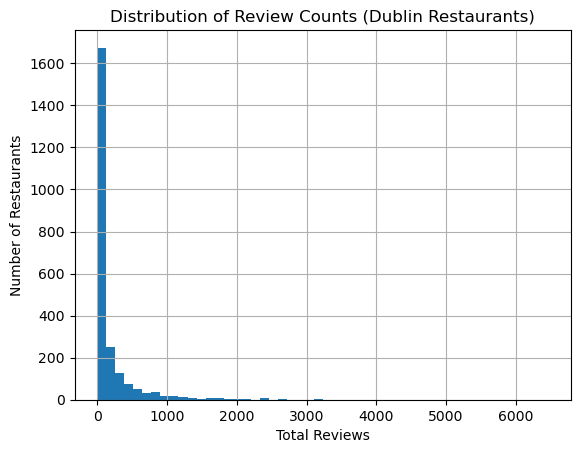

In [18]:
# distribution of total_reviews_count

dublin_clean["total_reviews_count"].hist(bins=50)
plt.title("Distribution of Review Counts (Dublin Restaurants)")
plt.xlabel("Total Reviews")
plt.ylabel("Number of Restaurants")
plt.show()

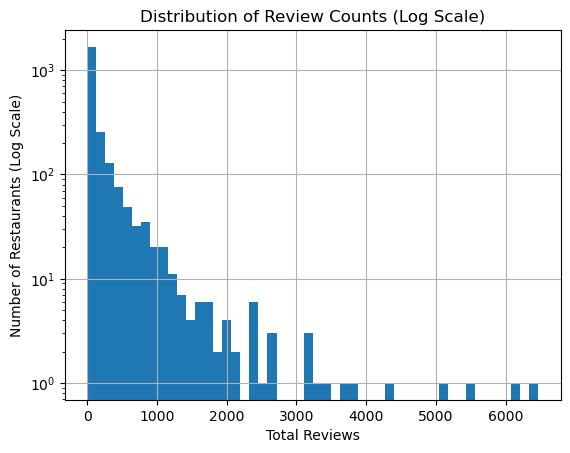

In [19]:
# the raw distribution is dominated by the first bar (very tall)
# a log scale is used to reveal the long tail more clearly

dublin_clean["total_reviews_count"].hist(bins=50)
plt.title("Distribution of Review Counts (Log Scale)")
plt.xlabel("Total Reviews")
plt.ylabel("Number of Restaurants (Log Scale)")
plt.yscale("log")
plt.show()

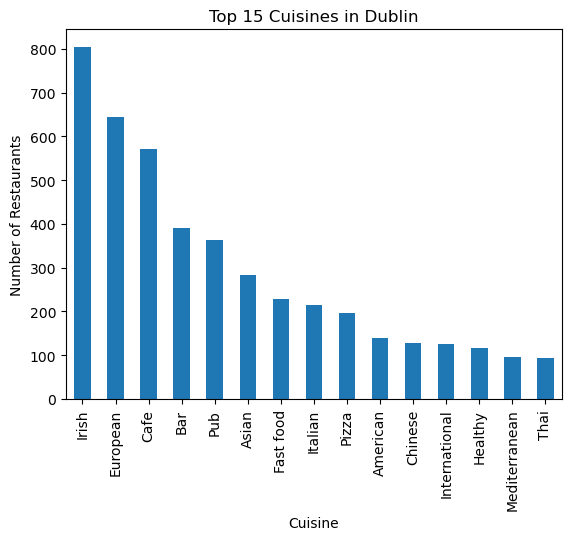

In [20]:
# top cuisines as bar chart

# splitting the comma-separated cuisines & count each one individually
cuisine_counts = dublin_clean["cuisines"].dropna().str.split(", ").explode().value_counts()

# plotting the top 15
cuisine_counts.head(15).plot(kind="bar")
plt.title("Top 15 Cuisines in Dublin")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.show()